## Annotation of Lymphocyte subset

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3               
sc.logging.print_version_and_date()

# making sure plots & clusters are reproducible
np.random.seed(42)

# custom functions
import ma_codes as codes
from ma_codes import mysize, mymap, gray_red

Running Scanpy 1.6.1.dev110+gb4234d81, on 2021-02-26 13:18.


In [2]:
## path variables
adata_path = 'mnt/smb2/Niklas/GLPG_data_temp/subsets/210211_lymphocyte_subset_NIKLAS.h5ad'

In [3]:
## plotting variables
sc.settings.figdir = '/home/agando/Documents/Niklas/Projects/niche_environments_FIBROSIS/GLPG_full_bleomycin_10X_MICE/Figures/lymphocyte_subset'
sc.set_figure_params(vector_friendly = True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [4]:
## load anndata object
adata = sc.read(adata_path)

In [5]:
## have a look at the adata object
adata

AnnData object with n_obs × n_vars = 177689 × 25194
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'GLPG_annotation', 'doublet_scores', 'n_genes', 'louvain_1', 'louvain_2'
    var: 'means', 'dispersions', 'dispersions_norm', 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'GLPG_annotation_colors', 'cluster_03_colors', 'condition_colors', 'hvg', 'identifier_colors', 'louvain', 'louvain_1_colors', 'neighbors', 'pca', 'time_point_colors', 'treatment_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'unsouped_counts'
    obsp: 'connectivities', 'distances'

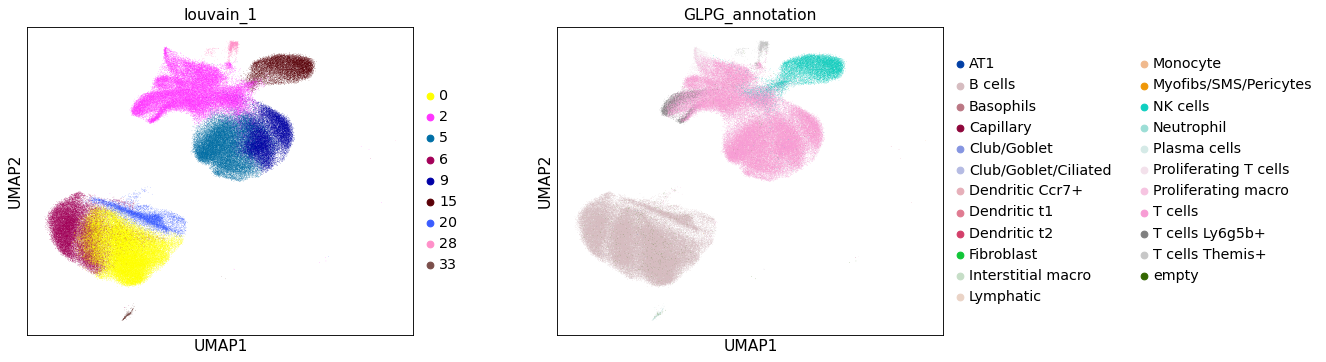

In [6]:
## overview plot
sc.pl.umap(adata, color = ['louvain_1', 'GLPG_annotation'], wspace = .25)

### Remove outliers with DBscan

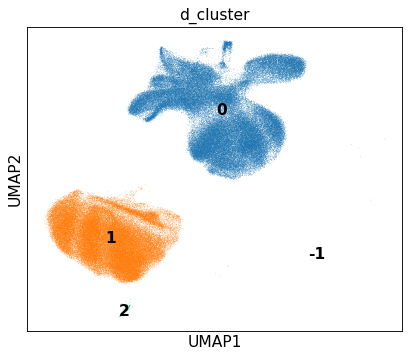

In [7]:
## using Herbert's old code snippet here
from natsort import natsorted
from sklearn.cluster import DBSCAN
def cluster_by_dscan(cords, eps, min_samples):
    clustering = DBSCAN(eps = eps, min_samples = min_samples).fit(cords)
    return clustering.labels_

adata.obs['d_cluster'] = cluster_by_dscan(adata.obsm['X_umap'], eps = 0.5, min_samples = 5)
c = adata.obs['d_cluster'].astype("U")
adata.obs['d_cluster'] = pd.Categorical(c, categories = natsorted(np.unique(c)))

sc.pl.umap(adata, color = 'd_cluster', legend_loc='on data')

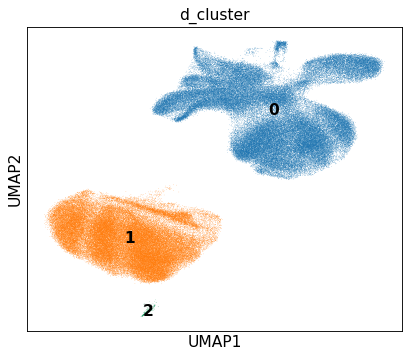

In [8]:
## discard outliers
adata = adata[adata.obs['d_cluster'].isin(['0','1','2'])].copy()
sc.pl.umap(adata, color = 'd_cluster', legend_loc='on data')

### Calculate HVGs

In [9]:
## delete all obs colums related to highly variable genes
del(adata.var['highly_variable'])
del(adata.var['highly_variable_nbatches'])
del(adata.var['highly_variable_intersection'])

In [10]:
## filter genes
sc.pp.filter_genes(adata, min_counts = 1)
sc.pp.filter_genes(adata, min_cells = 10)

filtered out 1053 genes that are detected in less than 1 counts
filtered out 3046 genes that are detected in less than 10 cells


extracting highly variable genes
/home/agando/anaconda3/lib/python3.7/site-packages/pandas/core/indexing.py:670: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iloc._setitem_with_indexer(indexer, value)
    finished (0:00:26)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
/home/agando/anaconda3/lib/python3.7/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


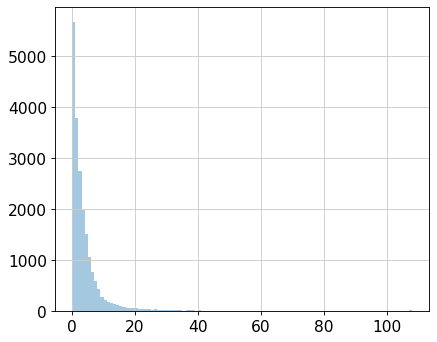

In [11]:
## compute HVGs per batch ('identifier') using seurat method
batch = 'identifier'
sc.pp.highly_variable_genes(adata, min_disp = None, max_disp = None, min_mean = None, max_mean = None, 
                                batch_key = batch, n_top_genes = 1000, n_bins = 20, flavor = 'seurat', 
                                subset = False)
vartab = pd.DataFrame(adata.var['highly_variable_nbatches'], index = adata.var_names)
sb.distplot(vartab, kde = False, bins = len(np.unique(adata.obs[batch])))

In [12]:
## only consider a gene as variable if variable in at least 7 batches
thresh = 7
hvgs = vartab[vartab.highly_variable_nbatches.values >= thresh].index
print('%s Genes kept, variable in at least %s samples' %(len(hvgs), thresh))

3574 Genes kept, variable in at least 7 samples


In [13]:
## remove cell cycle genes (MOUSE) from list of HVGs
cc_genes = [x.strip().capitalize() for x in open('/home/agando/Documents/Meshal/PhD_Scripts/' +
                                                 'for_orientation/regev_lab_cell_cycle_genes.txt')]
hvgs = np.setdiff1d(hvgs, cc_genes)

In [14]:
## set HVGs
adata.var['highly_variable'] = [g in hvgs for g in adata.var_names]
## no. of resulting HVGs
sum(adata.var['highly_variable'])

3520

In [15]:
## check if Malat1 in HVGs
adata.var['highly_variable']['Malat1']

False

### PCA

computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:13)


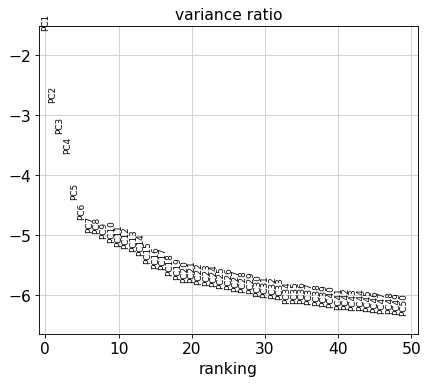

In [16]:
## PCA
sc.pp.pca(adata, use_highly_variable = True)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

### kNN graph

In [17]:
sc.pp.neighbors(adata, n_pcs = 50, n_neighbors = 30) # without batch correction

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:03:09)


### Graph-based clustering and Visualization

running Louvain clustering
    using the "louvain" package of Traag (2017)
    finished: found 21 clusters and added
    'sub_louvain', the cluster labels (adata.obs, categorical) (0:01:50)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:03:18)


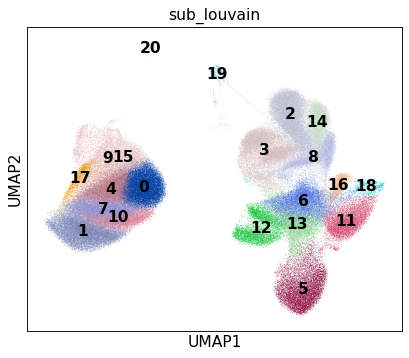

In [18]:
sc.tl.louvain(adata, resolution = 1.5, key_added = 'sub_louvain')
sc.tl.umap(adata)
sc.pl.umap(adata, color = ['sub_louvain'], legend_loc = 'on data')

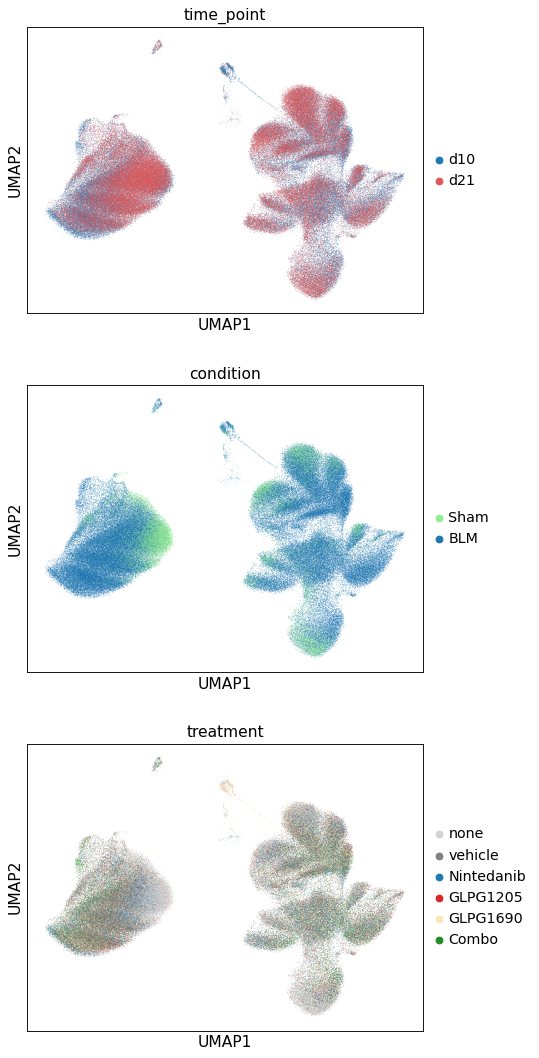

In [19]:
sc.pl.umap(adata, color = ['time_point', 'condition', 'treatment'], ncols = 1)

### Plot QC metrics

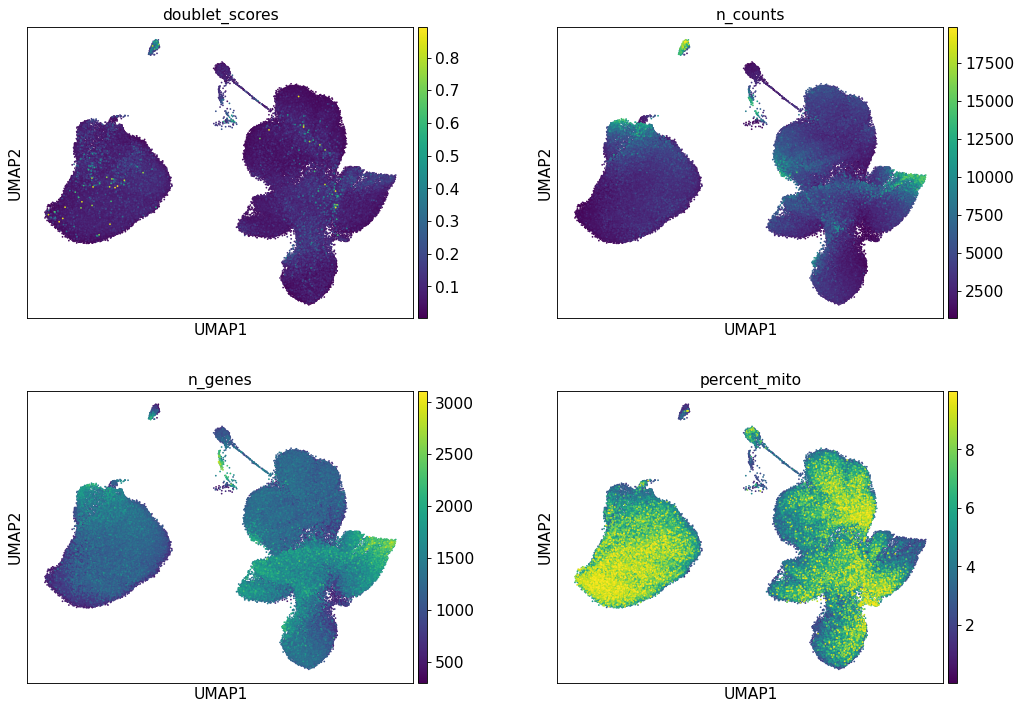

In [20]:
sc.pl.umap(adata, color = ['doublet_scores', 'n_counts', 'n_genes', 'percent_mito'], ncols = 2, wspace = 0.25, size = 10)

### Plot marker genes

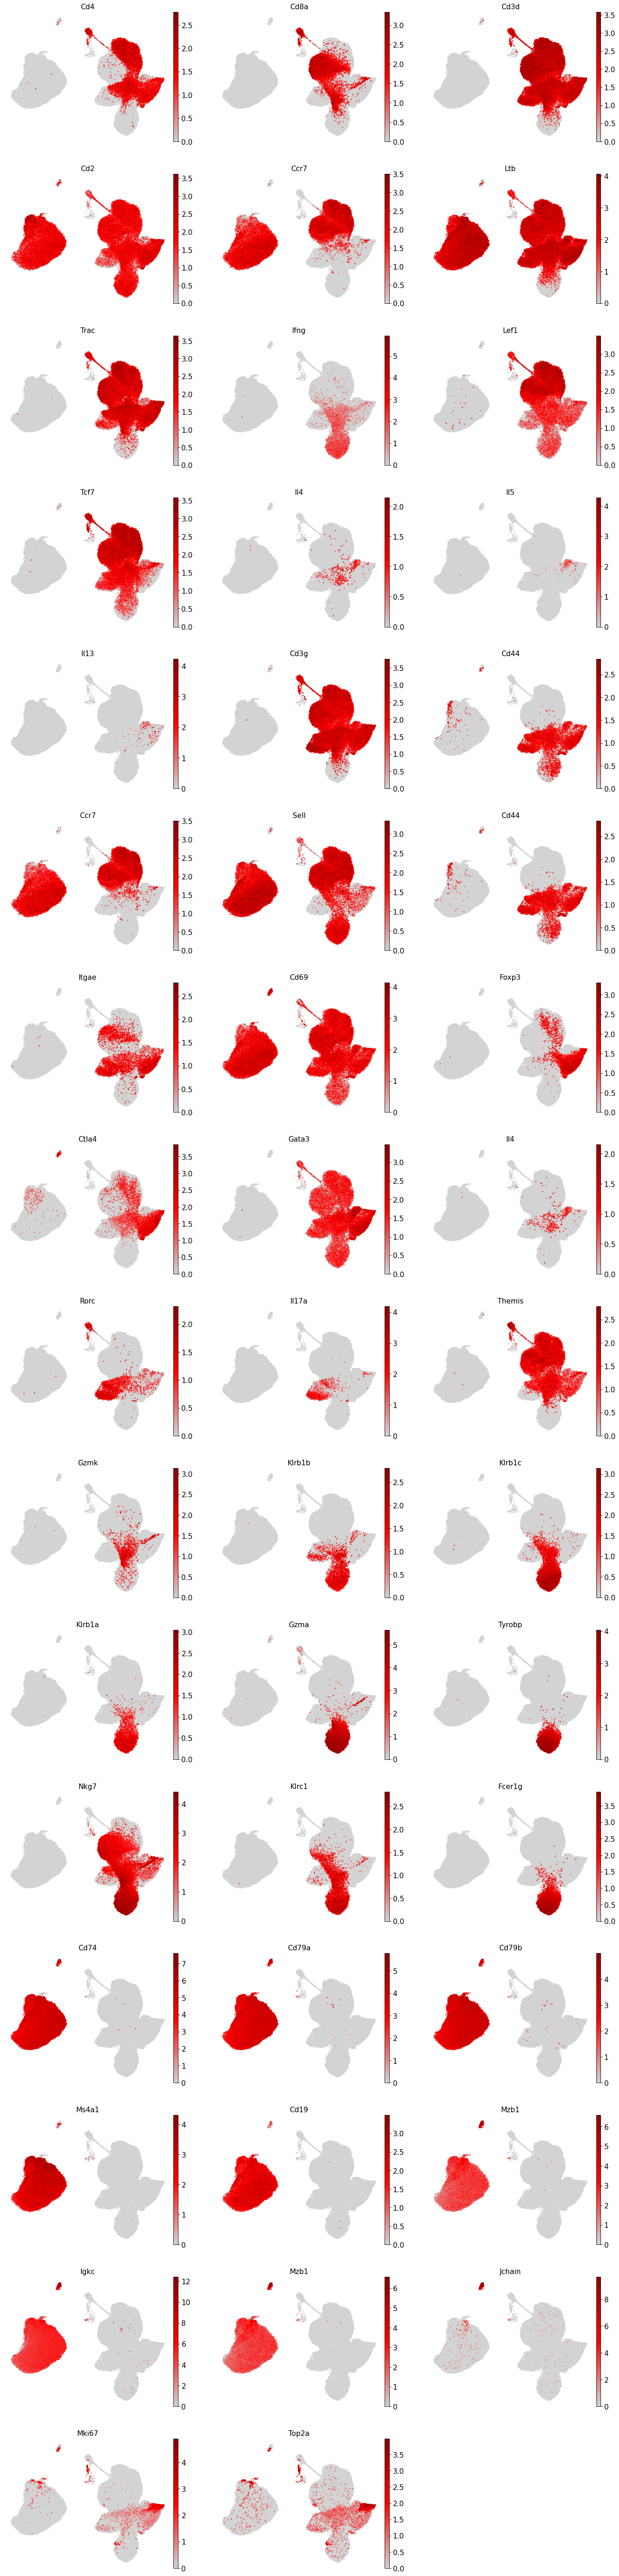

In [21]:
sc.pl.umap(adata, color = ['Cd4','Cd8a','Cd3d','Cd2','Ccr7','Ltb','Trac', # generic
                           'Ifng','Lef1','Tcf7','Il4','Il5','Il13', 'Cd3g','Cd44', # generic
                           'Ccr7','Sell','Cd44','Itgae', 'Cd69', # T memory
                           'Foxp3','Ctla4', # T reg
                           'Gata3','Il4', # Th2
                           'Rorc','Il17a', # Th17
                           'Themis', # Themis + 
                           'Gzmk', 'Klrb1b', 'Klrb1c', 'Klrb1a', # NK T cells
                           'Gzma','Tyrobp','Nkg7','Klrc1', 'Fcer1g', # NK cells
                           'Cd74', 'Cd79a','Cd79b','Ms4a1', # B cells
                           'Cd19','Mzb1','Igkc','Mzb1','Jchain',  # Plasma cells
                           'Mki67', 'Top2a' # Proliferation
                          ], ncols=3, size=20, frameon = False,
           color_map=gray_red)

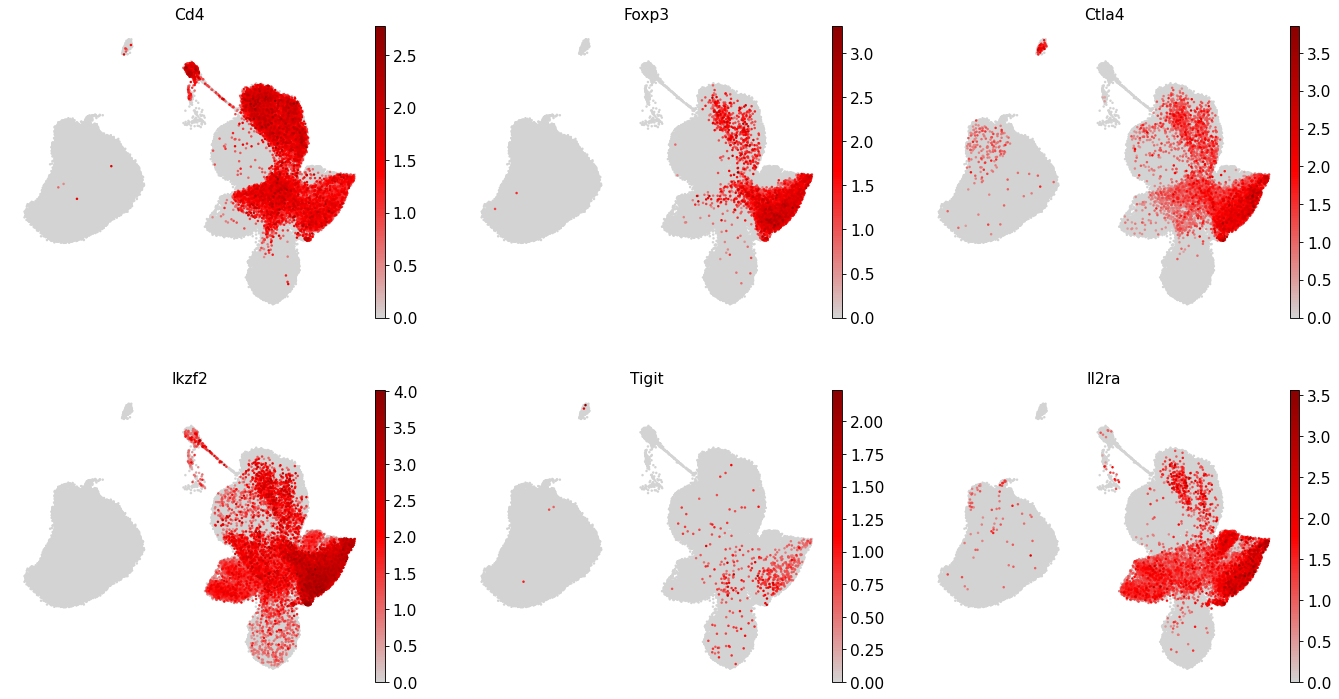

In [22]:
## T reg marker
sc.pl.umap(adata, color = ['Cd4','Foxp3','Ctla4','Ikzf2','Tigit','Il2ra'], ncols=3, size=20, frameon = False,
           color_map=gray_red)

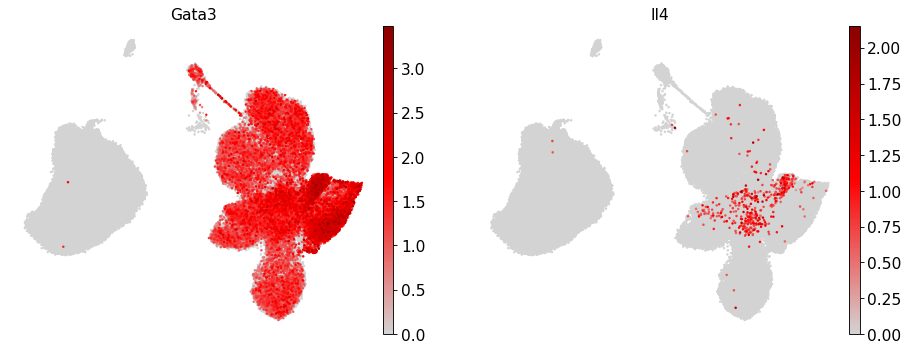

In [23]:
## Th2 marker genes
sc.pl.umap(adata, color = ['Gata3','Il4'], ncols=3, size=20, frameon = False, color_map=gray_red)

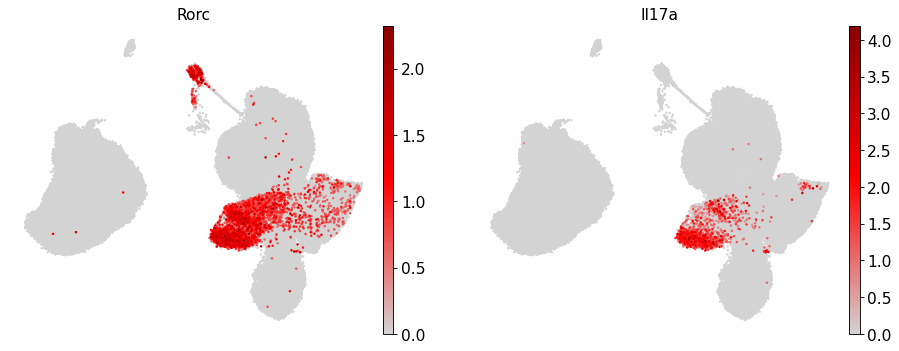

In [24]:
## Th17 marker
sc.pl.umap(adata, color = ['Rorc','Il17a'], ncols=3, size=20, frameon = False, color_map=gray_red)

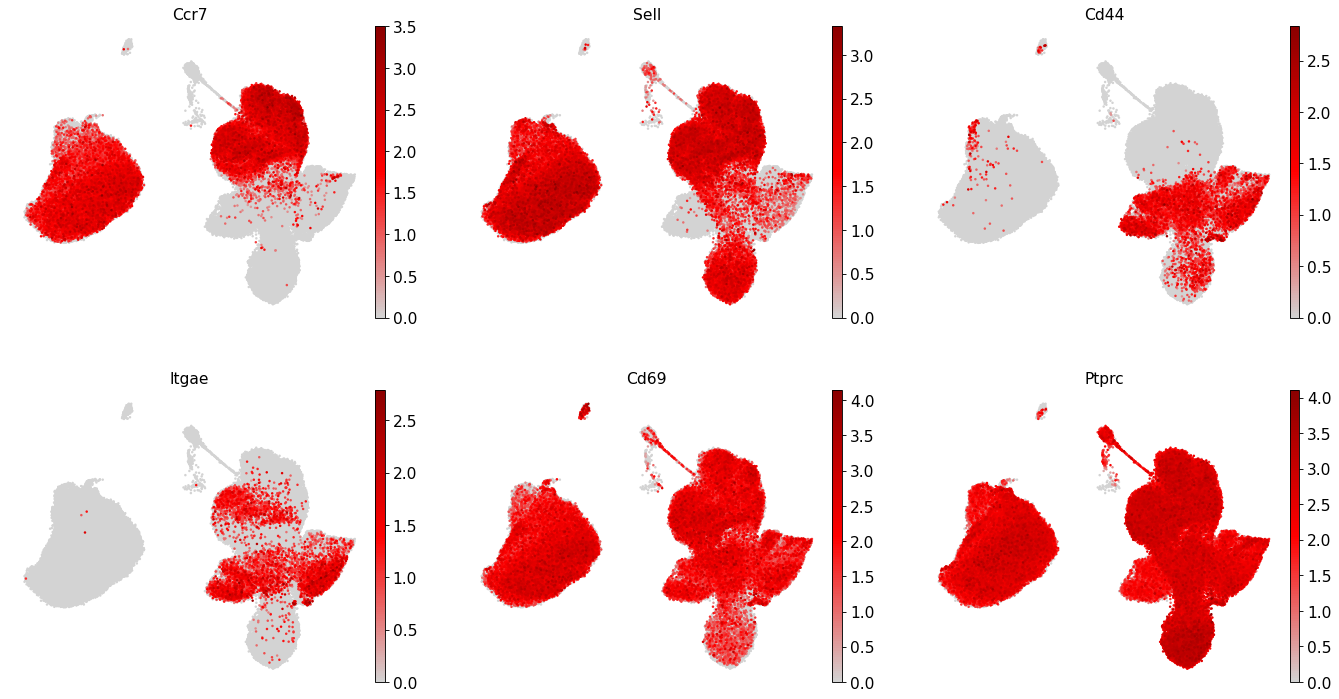

In [25]:
# T memory marker
sc.pl.umap(adata, color = ['Ccr7','Sell','Cd44','Itgae', 'Cd69','Ptprc'], ncols=3, size=20, frameon = False,
           color_map=gray_red)

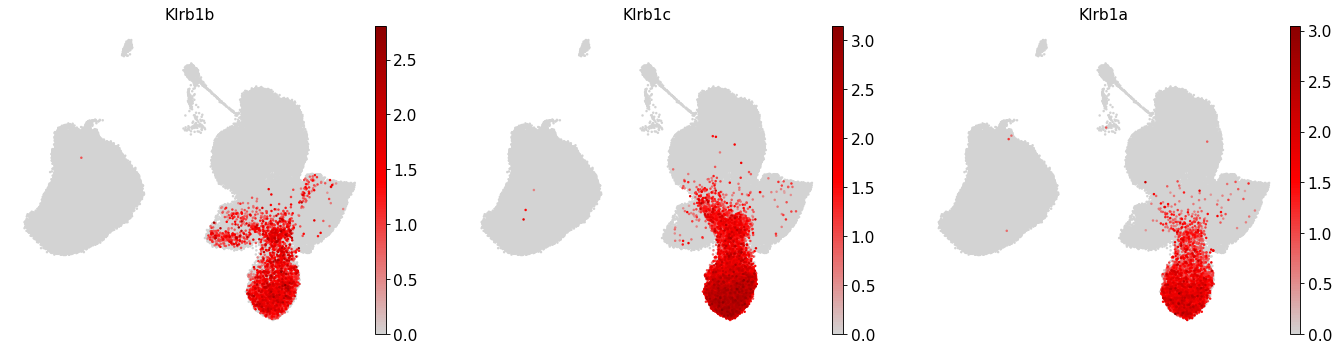

In [26]:
## NK T cell marker
sc.pl.umap(adata, color = ['Klrb1b', 'Klrb1c', 'Klrb1a'], ncols=3, size=20, frameon = False,
           color_map=gray_red)

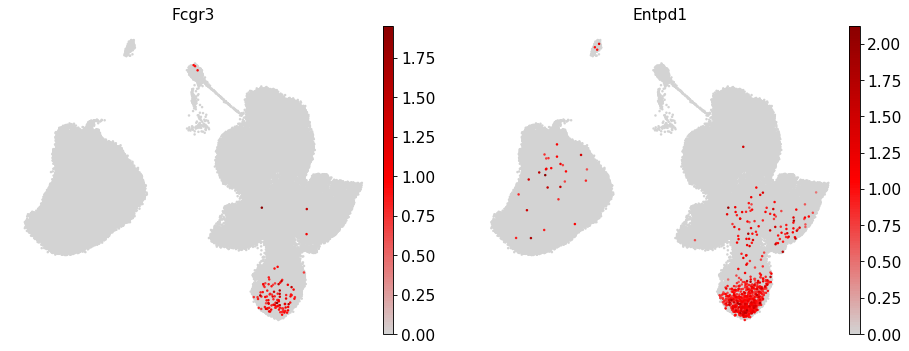

In [27]:
# NK cell marker
sc.pl.umap(adata, color = ['Fcgr3','Entpd1'], ncols=3, size=20, frameon = False, color_map=gray_red)

### Compute marker genes

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:04:57)


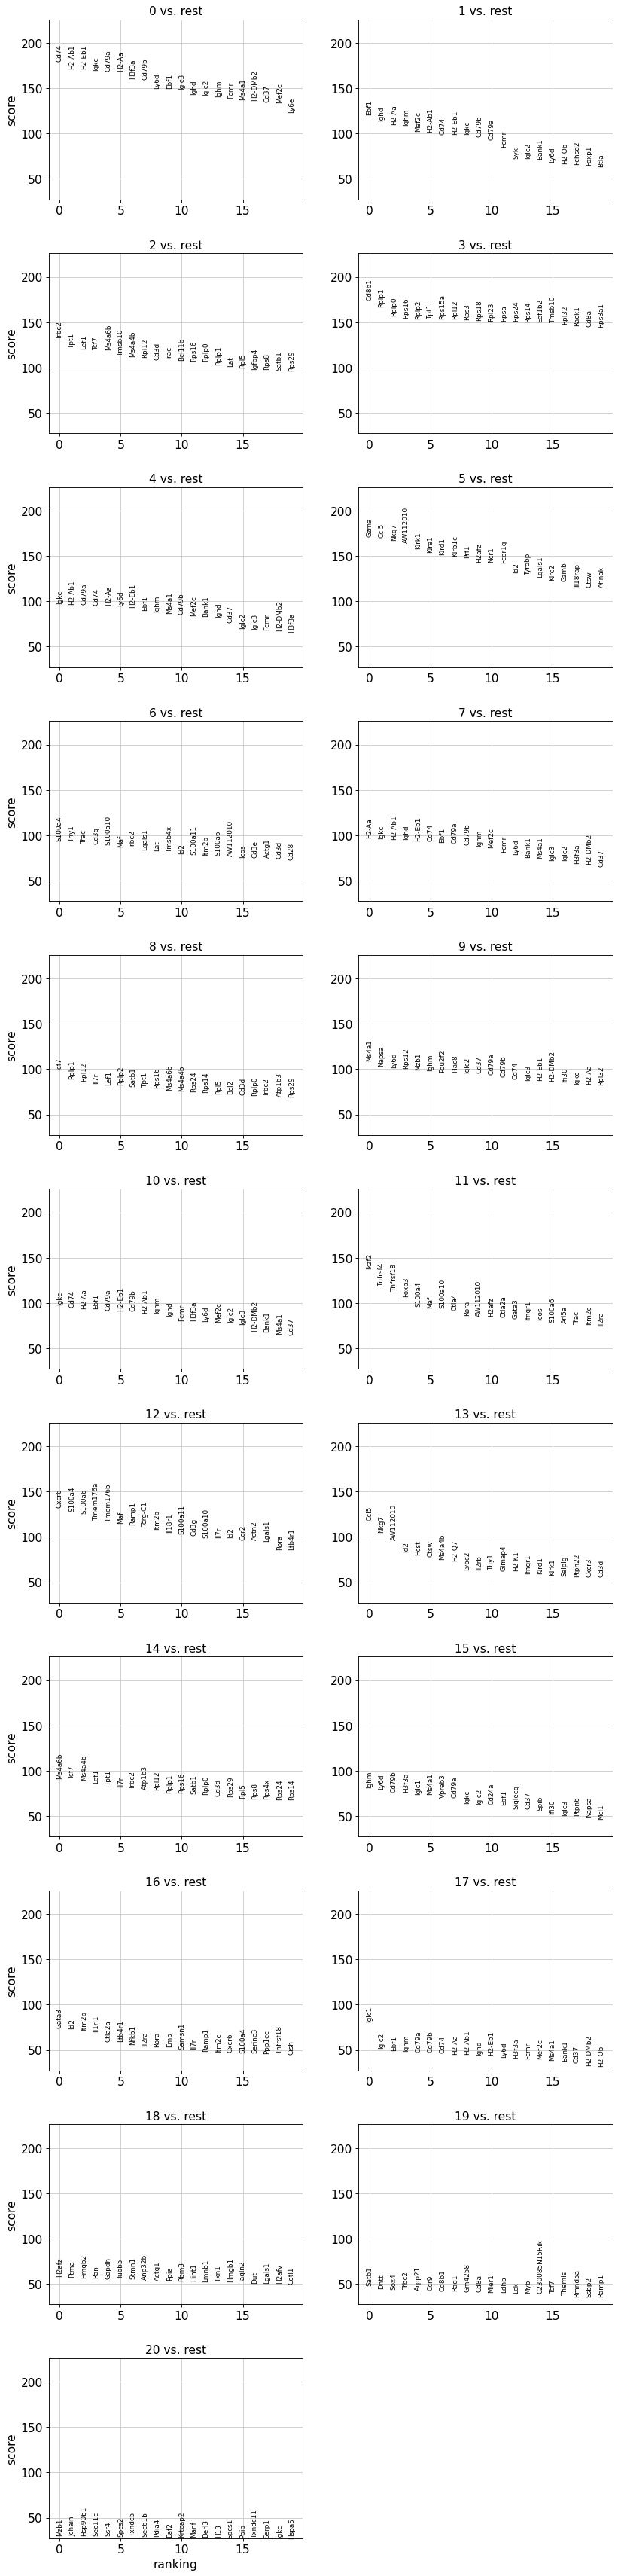

In [28]:
sc.tl.rank_genes_groups(adata, groupby = 'sub_louvain', groups = 'all', use_raw = True, method = 'wilcoxon', 
                        n_genes=100)
sc.pl.rank_genes_groups(adata, ncols = 2)

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_sub_louvain']`


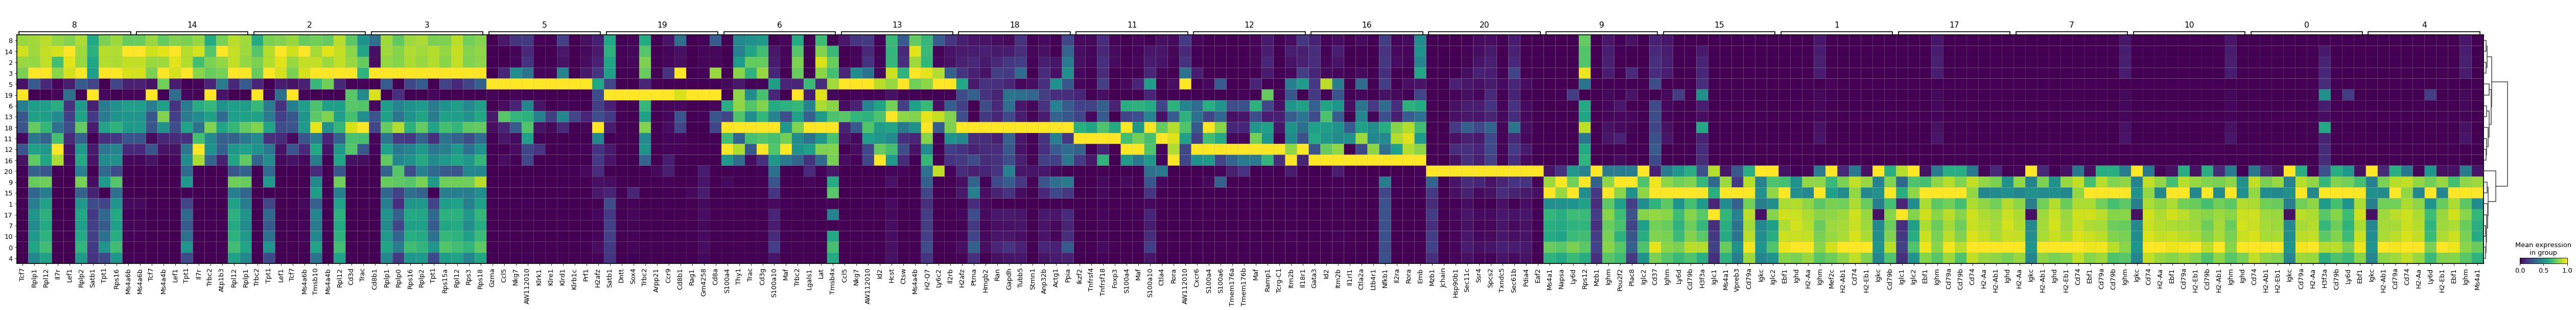

In [29]:
## find markers
sc.tl.dendrogram(adata, groupby = 'sub_louvain')
#sc.tl.rank_genes_groups(adata, groupby = 'sub_louvain', method = 'wilcoxon')
sc.pl.rank_genes_groups_matrixplot(adata, n_genes = 10, standard_scale = 'var')

### Cluster Annotation

... storing 'cell_type' as categorical


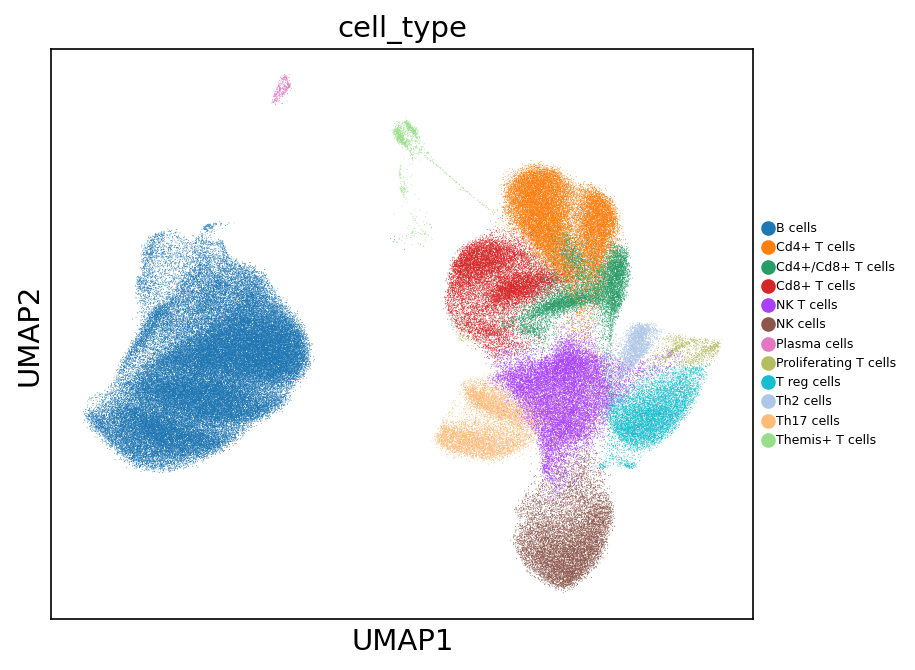

In [30]:
cell_type = {'0' : 'B cells',
             '1' : 'B cells',
             '2' : 'Cd4+ T cells',
             '3' : 'Cd8+ T cells',
             '4' : 'B cells',
             '5' : 'NK cells',
             '6' : 'NK T cells',
             '7' : 'B cells',
             '8' : 'Cd4+/Cd8+ T cells',
             '9' : 'B cells',
             '10' : 'B cells',
             '11' : 'T reg cells',
             '12' : 'Th17 cells',
             '13' : 'NK T cells',
             '14' : 'Cd4+ T cells',
             '15' : 'B cells',
             '16' : 'Th2 cells',
             '17' : 'B cells',
             '18' : 'Proliferating T cells',
             '19' : 'Themis+ T cells',
             '20' : 'Plasma cells',
            }

adata.obs['cell_type'] = [cell_type[cluster] for cluster in adata.obs['sub_louvain']]
sc.pl.umap(adata, color = 'cell_type', ax = mysize(6, 5, 150), legend_fontsize = 6)

### Remove low-quality cells and re-calculate UMAP

In [ ]:
## not necessary, since we did not remove any cells

### Re-calculate markers (of final annotated cell type clusters)

In [31]:
## All Markers
sc.tl.rank_genes_groups(adata, groupby = 'cell_type', n_genes = 500, groups = 'all',
                        use_raw = True, method = 'wilcoxon')

## Combine into one Data Frame (comparable to Marker Table)
result = adata.uns['rank_genes_groups']
allMarkers = []
for cluster in result['names'].dtype.names:
    current = pd.DataFrame({'gene': result['names'][cluster], 'score': result['scores'][cluster],
                            'logfoldchange': result['logfoldchanges'][cluster], 'pval': result['pvals'][cluster],
                            'pval_adj': result['pvals_adj'][cluster], 'cell_type': cluster})
    allMarkers.append(current)
allMarkers = pd.concat(allMarkers)
allMarkers.head()

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:04:30)


,gene,score,logfoldchange,pval,pval_adj,cell_type
0,Cd74,361.380157,13.529374,0.0,0.0,B cells
1,Cd79a,359.684845,11.227908,0.0,0.0,B cells
2,Ighm,350.031342,6.305209,0.0,0.0,B cells
3,H2-Aa,350.028229,16.345984,0.0,0.0,B cells
4,Cd79b,349.592194,10.470890,0.0,0.0,B cells


In [32]:
## filter
allMarkers = allMarkers[allMarkers.pval_adj < 0.1].copy()
allMarkers.cell_type.value_counts()

NK T cells               500
Cd8+ T cells             500
Th17 cells               500
Cd4+ T cells             500
Plasma cells             500
Themis+ T cells          500
Proliferating T cells    500
T reg cells              500
Th2 cells                500
Cd4+/Cd8+ T cells        500
B cells                  500
NK cells                 500
Name: cell_type, dtype: int64

In [33]:
## save marker table
out_dir = '/home/agando/Documents/Niklas/Projects/niche_environments_FIBROSIS/GLPG_full_bleomycin_10X_MICE/Data/'
allMarkers.to_csv(out_dir + 'marker_table_GLPG_lymphocyte_subset_NIKLAS.csv', sep = '\t', index = False)

### Summary figures

In [34]:
adata.obs.cell_type.cat.categories

Index(['B cells', 'Cd4+ T cells', 'Cd4+/Cd8+ T cells', 'Cd8+ T cells',
       'NK T cells', 'NK cells', 'Plasma cells', 'Proliferating T cells',
       'T reg cells', 'Th2 cells', 'Th17 cells', 'Themis+ T cells'],
      dtype='object')

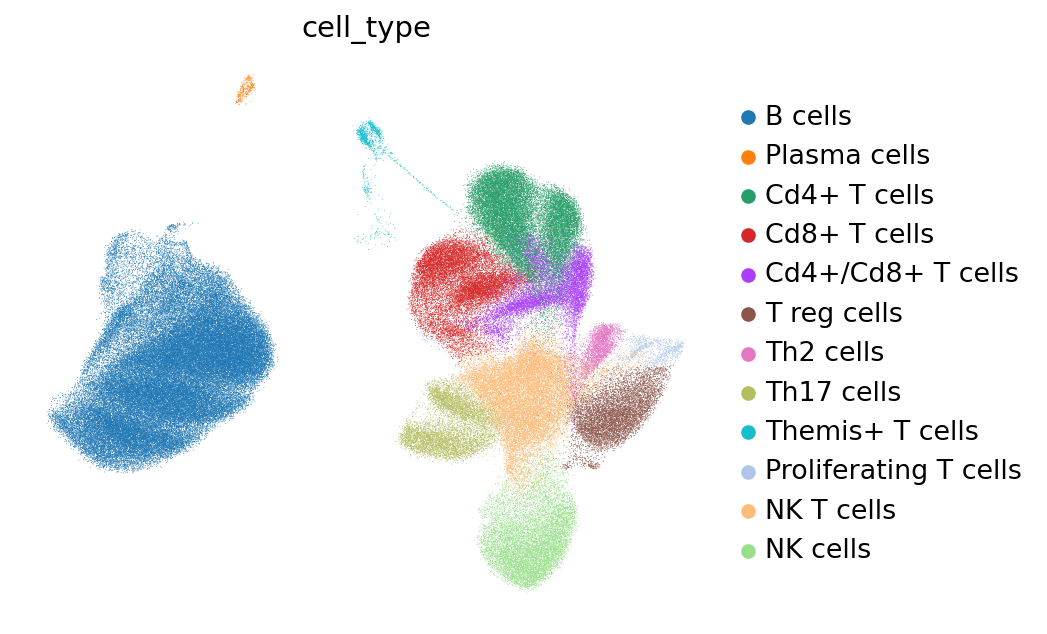

In [35]:
## change order of cell type labels
adata.obs['cell_type'] = adata.obs['cell_type'].cat.reorder_categories(['B cells',
                                                                        'Plasma cells',
                                                                        'Cd4+ T cells', 
                                                                        'Cd8+ T cells',
                                                                        'Cd4+/Cd8+ T cells',
                                                                        'T reg cells',
                                                                        'Th2 cells',
                                                                        'Th17 cells',
                                                                        'Themis+ T cells',
                                                                        'Proliferating T cells',
                                                                        'NK T cells',
                                                                        'NK cells'])
sc.pl.umap(adata, color = 'cell_type', ax = mysize(6, 5, 150), frameon = False)

... storing 'cell_type_compact' as categorical


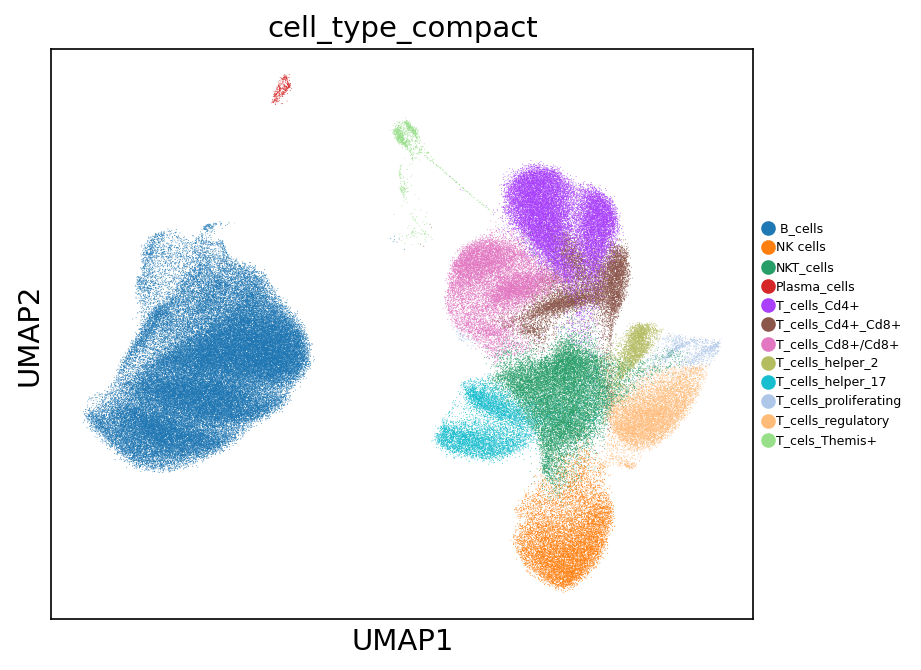

In [36]:
## special regex compatible cell type labels for GLPG :)
cell_type_conversion = {'B cells' : ' B_cells',
                        'Plasma cells' : 'Plasma_cells',
                        'Cd4+ T cells' : 'T_cells_Cd4+', 
                        'Cd8+ T cells' : 'T_cells_Cd8+/Cd8+',
                        'Cd4+/Cd8+ T cells' : 'T_cells_Cd4+_Cd8+',
                        'Proliferating T cells' : 'T_cells_proliferating',
                        'T reg cells' : 'T_cells_regulatory',
                        'Th2 cells' : 'T_cells_helper_2',
                        'Th17 cells' : 'T_cells_helper_17',
                        'Themis+ T cells' : 'T_cels_Themis+',
                        'NK T cells' : 'NKT_cells',
                        'NK cells' : 'NK cells'
}
adata.obs['cell_type_compact'] = [cell_type_conversion[cluster] for cluster in adata.obs['cell_type']]
sc.pl.umap(adata, color = 'cell_type_compact', ax = mysize(6, 5, 150), legend_fontsize = 6)

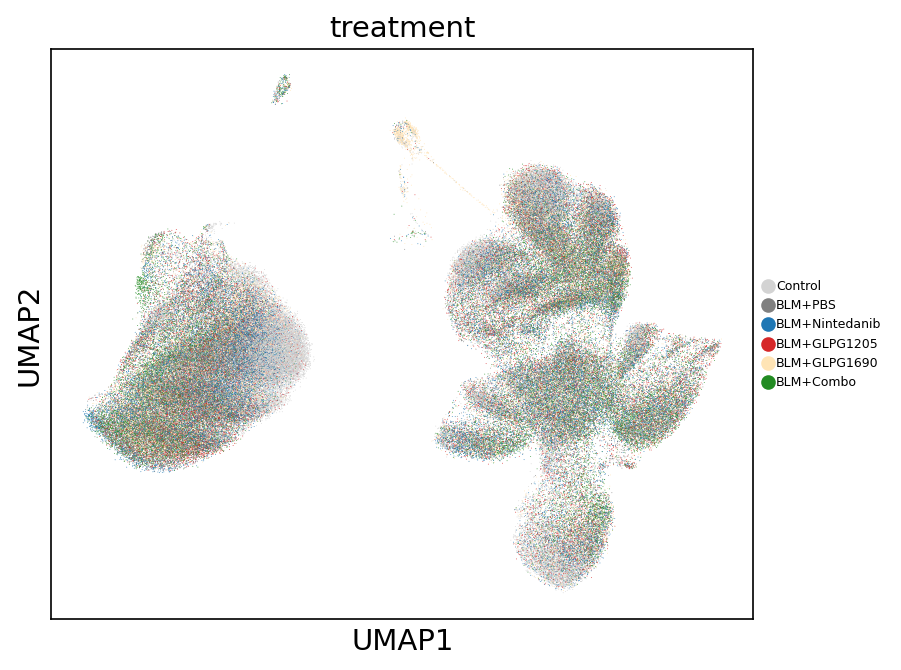

In [37]:
# rename condition label upon request of GLPG :)
treatment_conversion = {'none' : 'Control',
                        'vehicle' : 'BLM+PBS',
                        'Nintedanib' : 'BLM+Nintedanib',
                        'GLPG1205' : 'BLM+GLPG1205',
                        'GLPG1690' : 'BLM+GLPG1690',
                        'Combo' : 'BLM+Combo'
}
adata.obs['treatment'] = [treatment_conversion[t] for t in adata.obs['treatment']]
## reorder condition labels
adata.obs['treatment'] = adata.obs['treatment'].astype('category')
adata.obs['treatment'] = adata.obs['treatment'].cat.reorder_categories(['Control','BLM+PBS',
                                                                        'BLM+Nintedanib',
                                                                        'BLM+GLPG1205',
                                                                        'BLM+GLPG1690',
                                                                        'BLM+Combo'])
## plot UMAPs with new labels
sc.pl.umap(adata, color = 'treatment', ax = mysize(6, 5, 150), legend_fontsize = 6)

... storing 'treatment_time' as categorical


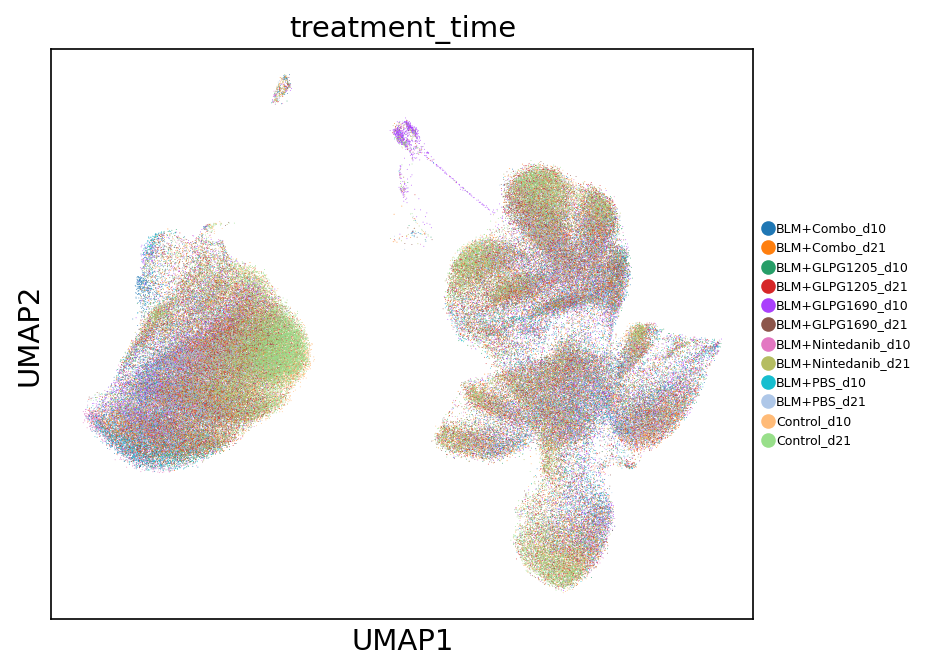

In [38]:
## rename treatment_time label upon request of GLPG :)
treatment_time_conversion = {'none_d10' : 'Control_d10',
                             'none_d21' : 'Control_d21',
                             'vehicle_d10' : 'BLM+PBS_d10',
                             'vehicle_d21' : 'BLM+PBS_d21',
                             'Nintedanib_d10' : 'BLM+Nintedanib_d10',
                             'Nintedanib_d21' : 'BLM+Nintedanib_d21',
                             'GLPG1205_d10' : 'BLM+GLPG1205_d10',
                             'GLPG1205_d21' : 'BLM+GLPG1205_d21',
                             'GLPG1690_d10' : 'BLM+GLPG1690_d10',
                             'GLPG1690_d21' : 'BLM+GLPG1690_d21',
                             'Combo_d10' : 'BLM+Combo_d10',
                             'Combo_d21' : 'BLM+Combo_d21'
}
adata.obs['treatment_time'] = [treatment_time_conversion[tt] for tt in adata.obs['treatment_time']]
sc.pl.umap(adata, color = 'treatment_time', ax = mysize(6, 5, 150), legend_fontsize = 6)

In [39]:
adata.obs.cell_type.cat.categories

Index(['B cells', 'Plasma cells', 'Cd4+ T cells', 'Cd8+ T cells',
       'Cd4+/Cd8+ T cells', 'T reg cells', 'Th2 cells', 'Th17 cells',
       'Themis+ T cells', 'Proliferating T cells', 'NK T cells', 'NK cells'],
      dtype='object')

In [40]:
## custom colors to highlight differences between cell types
celltype_colours = ['#65209b', # B cells
                    '#ef6bf1', # Plasma cells
                    '#fc9983', # Cd4+ T cells
                    '#d62728', # Cd8+ T cells
                    '#ff7f0e', # Cd4+/Cd8+ T cells
                    '#f1c40f', # T reg cells
                    '#bdecf0', # Th2 cells
                    '#bb7784', # Th17 cells
                    '#4be7b0', # Themis+ T cells
                    '#1e37d4', # Proliferating T cells
                    '#bfe9ac', # NK T cells
                    '#138310', # NK cells
                   ]

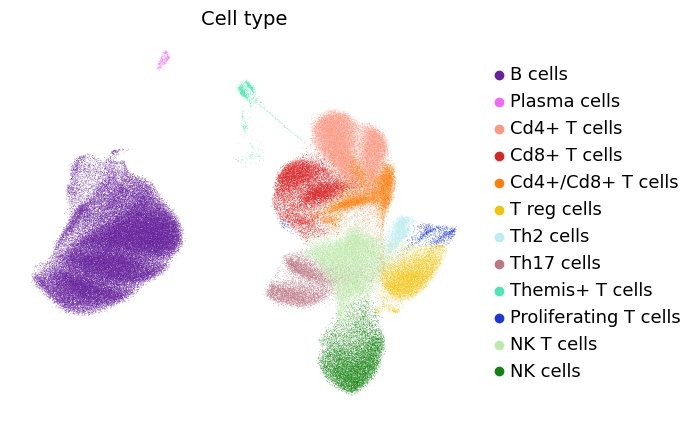

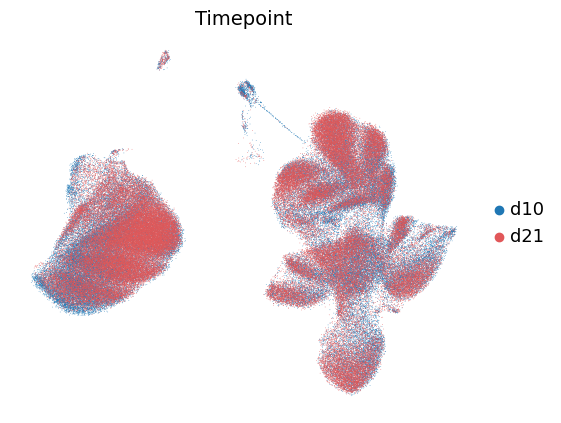

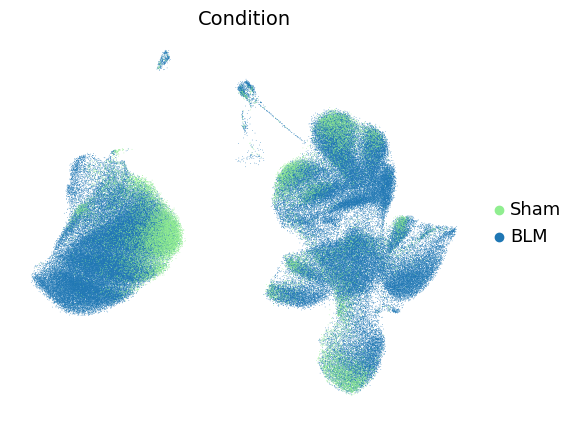

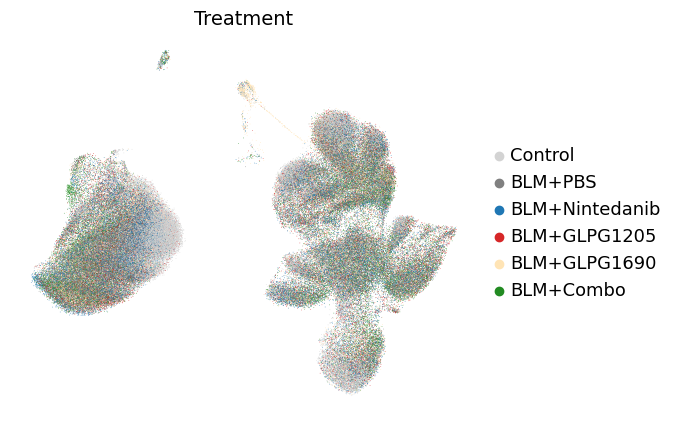

In [41]:
## save UMAP of MNPs for future use
sc.pl.umap(adata, color = ['cell_type'], title = 'Cell type', palette = celltype_colours, frameon = False, 
           ax = mysize(6, 5, 100), save = '_celltype.pdf')
sc.pl.umap(adata, color = ['time_point'], title = 'Timepoint', frameon = False, 
           ax = mysize(6, 5, 100), size = 1, save = '_timepoint.pdf')
sc.pl.umap(adata, color = ['condition'], title = 'Condition', frameon = False, 
           ax = mysize(6, 5, 100), size = 1, save = '_condition.pdf')
sc.pl.umap(adata, color = ['treatment'], title = 'Treatment', frameon = False, 
           ax = mysize(6, 5, 100), size = 1, save = '_treatment.pdf')

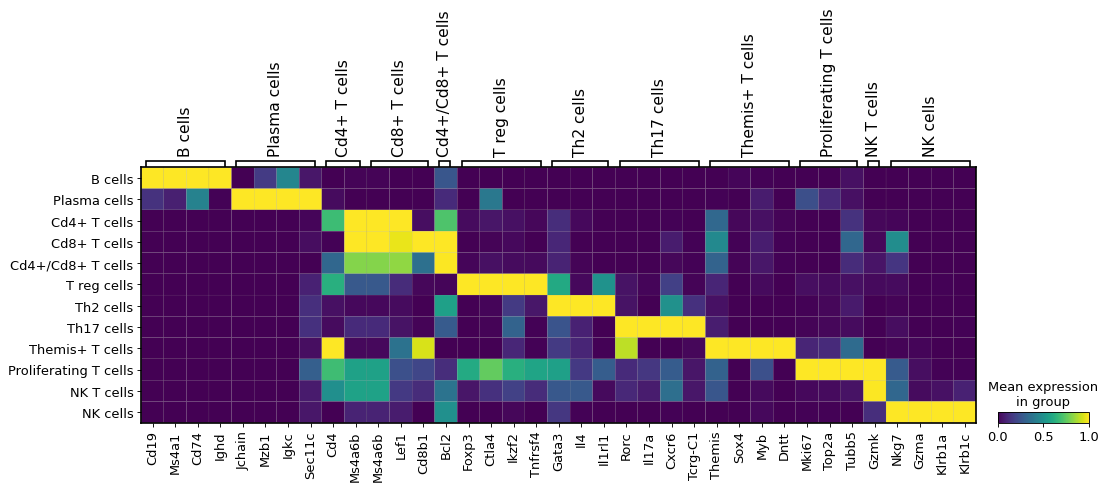

In [42]:
## custom heatmap
# matrixplot with marker genes
celltype_markers={'B cells' : ['Cd19','Ms4a1','Cd74','Ighd'],
                  'Plasma cells' : ['Jchain','Mzb1','Igkc','Sec11c'],
                  'Cd4+ T cells' : ['Cd4','Ms4a6b'],
                  'Cd8+ T cells' : ['Ms4a6b','Lef1','Cd8b1'],
                  'Cd4+/Cd8+ T cells' : ['Bcl2'],
                  'T reg cells' : ['Foxp3','Ctla4','Ikzf2','Tnfrsf4'],
                  'Th2 cells' : ['Gata3','Il4','Il1rl1'],
                  'Th17 cells' : ['Rorc','Il17a','Cxcr6','Tcrg-C1'],
                  'Themis+ T cells' : ['Themis','Sox4','Myb','Dntt'],
                  'Proliferating T cells' : ['Mki67','Top2a','Tubb5'],
                  'NK T cells' : ['Gzmk'], 
                  'NK cells' : ['Nkg7','Gzma','Klrb1a', 'Klrb1c']   
}
sc.pl.matrixplot(adata, celltype_markers, groupby = 'cell_type',standard_scale='var',
                 dendrogram=False, save='curated_marker_matrix.pdf')

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_cell_type']`


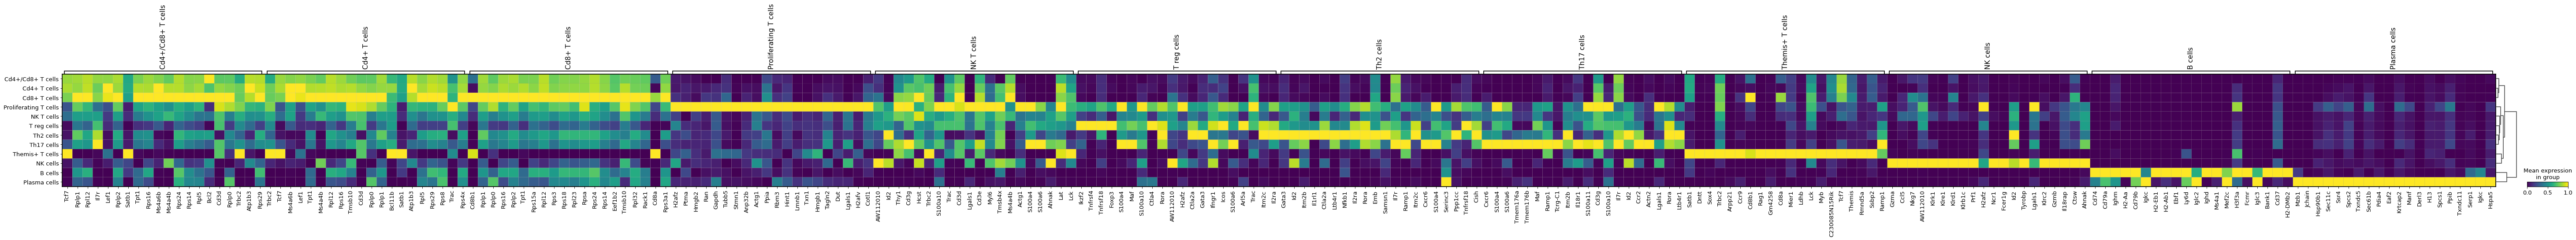

In [43]:
## automated heatmap
sc.tl.dendrogram(adata, groupby = 'cell_type')
#sc.tl.rank_genes_groups(adata, groupby = 'cell_type', method = 'wilcoxon')
sc.pl.rank_genes_groups_matrixplot(adata, n_genes = 20, standard_scale = 'var', save= 'auto_marker_matrix.pdf')

In [44]:
## frequency table
xlabel = 'treatment'
cell_types_label = 'cell_type'
cols = adata.uns['%s_colors' %cell_types_label]
celltypes = adata.obs[cell_types_label].cat.categories

relFreqs = codes.calc_relFreq(adata, group_by = cell_types_label, xlabel = xlabel, condition = None)
relFreqs.head(2)

,B cells,Plasma cells,Cd4+ T cells,Cd8+ T cells,Cd4+/Cd8+ T cells,T reg cells,Th2 cells,Th17 cells,Themis+ T cells,Proliferating T cells,NK T cells,NK cells,treatment
d100BLM_Combo48,0.496377,0.012077,0.012077,0.007246,0.205314,0.027778,0.010870,0.095411,0.001208,0.004831,0.09058,0.036232,BLM+Combo
d100BLM_G120528,0.514141,0.006526,0.088470,0.061639,0.080493,0.039159,0.015228,0.030457,0.000000,0.016679,0.10950,0.037708,BLM+GLPG1205


Saving Figure to /home/agando/Documents/Niklas/Projects/niche_environments_FIBROSIS/GLPG_full_bleomycin_10X_MICE/Figures/lymphocyte_subset/relfreqs_treatment.pdf


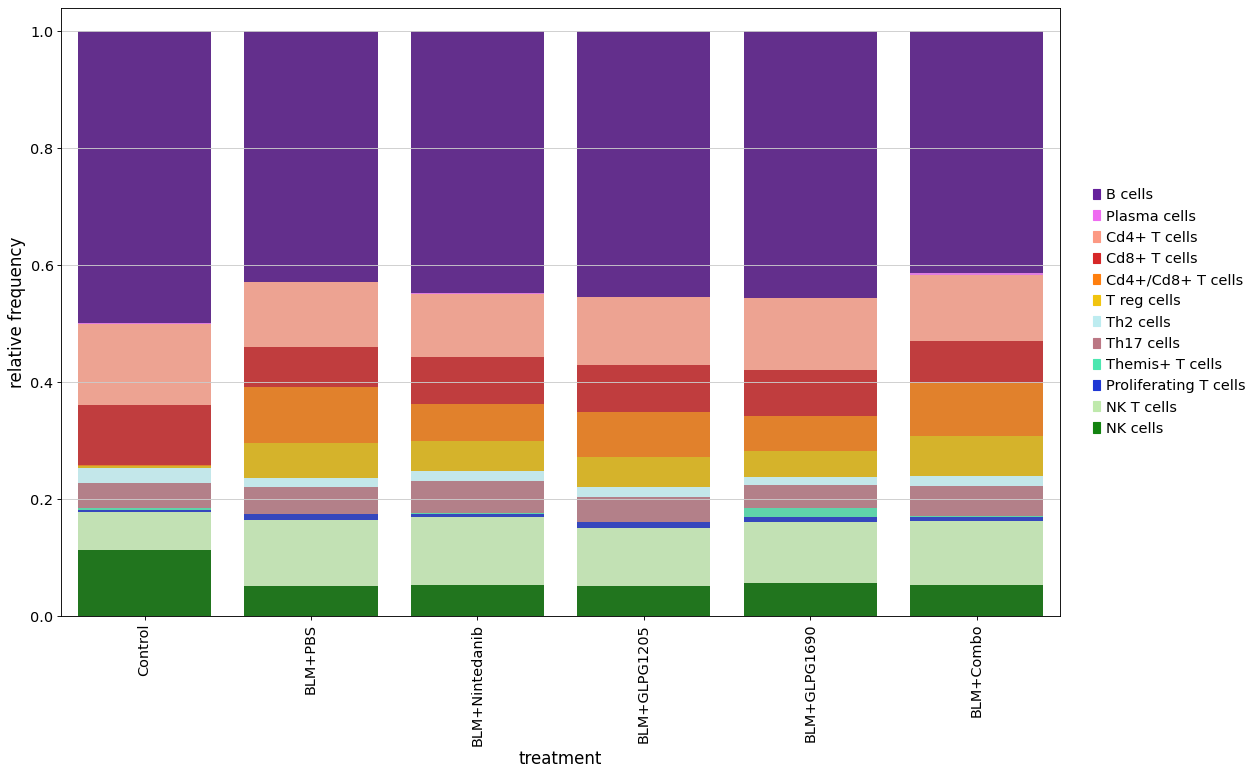

In [45]:
## cell type frequencies per treatment category
codes.plot_cluster_composition(relFreqs, xlabel = xlabel, figsize = (16,10), order = ['Control','BLM+PBS','BLM+Nintedanib','BLM+GLPG1205','BLM+GLPG1690','BLM+Combo'],
                               errbar = False, cols = cols, width = 0.8,
                               save='/home/agando/Documents/Niklas/Projects/niche_environments_FIBROSIS/GLPG_full_bleomycin_10X_MICE/Figures/lymphocyte_subset/relfreqs_treatment.pdf')

In [46]:
## frequency table
xlabel = 'treatment_time'
cell_types_label = 'cell_type'
cols = adata.uns['%s_colors' %cell_types_label]
celltypes = adata.obs[cell_types_label].cat.categories

relFreqs = codes.calc_relFreq(adata, group_by = cell_types_label, xlabel = xlabel, condition = None)
relFreqs.head(2)

,B cells,Plasma cells,Cd4+ T cells,Cd8+ T cells,Cd4+/Cd8+ T cells,T reg cells,Th2 cells,Th17 cells,Themis+ T cells,Proliferating T cells,NK T cells,NK cells,treatment_time
d100BLM_Combo48,0.496377,0.012077,0.012077,0.007246,0.205314,0.027778,0.010870,0.095411,0.001208,0.004831,0.09058,0.036232,BLM+Combo_d10
d100BLM_G120528,0.514141,0.006526,0.088470,0.061639,0.080493,0.039159,0.015228,0.030457,0.000000,0.016679,0.10950,0.037708,BLM+GLPG1205_d10


Saving Figure to /home/agando/Documents/Niklas/Projects/niche_environments_FIBROSIS/GLPG_full_bleomycin_10X_MICE/Figures/lymphocyte_subset/relfreqs_treatment_time.pdf


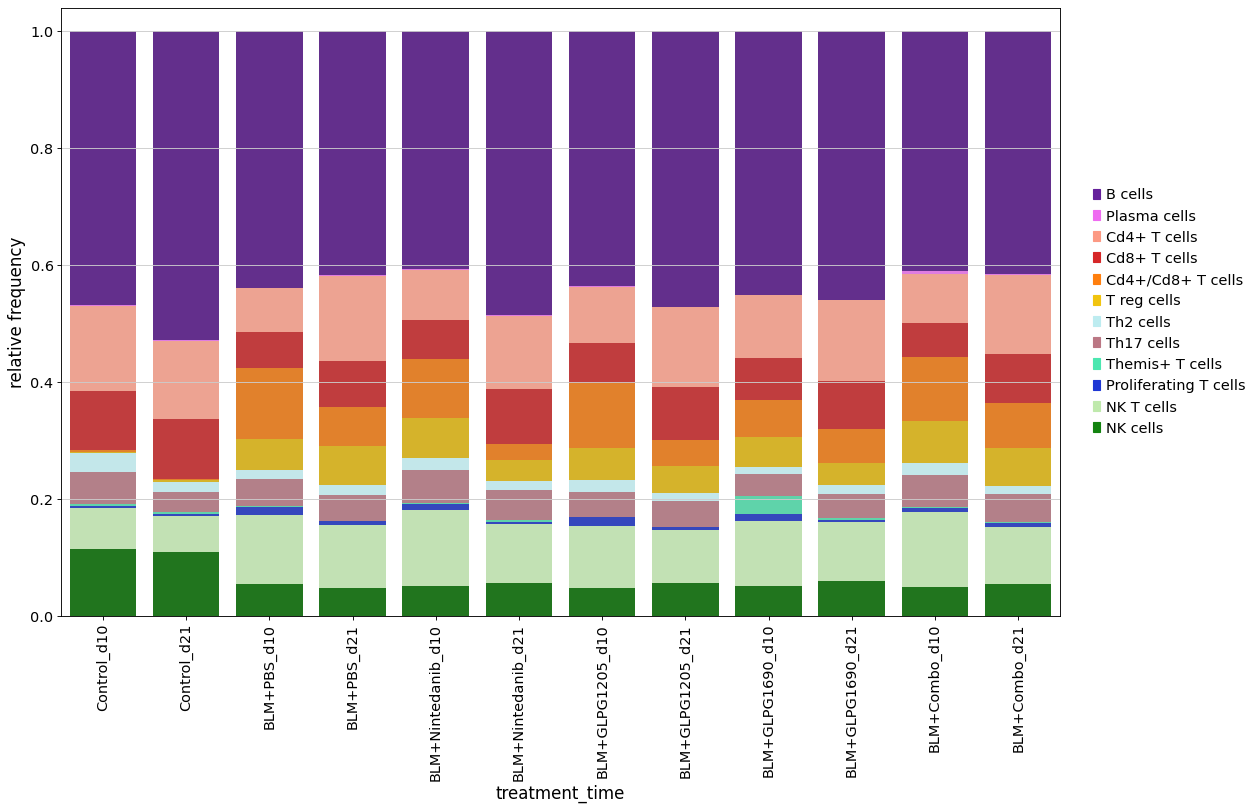

In [47]:
## cell type frequencies per treatment time category
codes.plot_cluster_composition(relFreqs, xlabel = xlabel, figsize = (16, 10),
            order = ['Control_d10','Control_d21','BLM+PBS_d10','BLM+PBS_d21','BLM+Nintedanib_d10','BLM+Nintedanib_d21',
                     'BLM+GLPG1205_d10','BLM+GLPG1205_d21','BLM+GLPG1690_d10','BLM+GLPG1690_d21','BLM+Combo_d10','BLM+Combo_d21'],
            errbar = False, cols = cols, width = 0.8, 
            save='/home/agando/Documents/Niklas/Projects/niche_environments_FIBROSIS/GLPG_full_bleomycin_10X_MICE/Figures/lymphocyte_subset/relfreqs_treatment_time.pdf')

### Save annotated subset

In [48]:
## save adata object
adata.write('/mnt/platte_1/Projects/210115_GLPG/subsets/210218_lymphocyte_subset_NIKLAS_annotated.h5ad')